# Modèles non linéaires — `/predict`

**Objectif :** comparer plusieurs modèles à la baseline linéaire et vérifier l'apport des variables supplémentaires.

Les modèles sont testés sans optimisation ; le tuning viendra plus tard.

## Imports

In [1]:
import time

import numpy as np
import pandas as pd
import shap
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from agritech.config import SEED
from agritech.evaluation import cross_validate_folds, format_cv_metrics, summarize_cv_folds
from agritech.notification import notify
from agritech.preprocessing import PREPROCESSING_DESCRIPTION, build_pipeline, count_encoded_columns
from agritech.tracking import log_run, run_tags, setup_mlflow
from agritech.training_data import (
    PREDICT_BUSINESS_FEATURES,
    PREDICT_CATEGORICAL,
    PREDICT_FEATURES,
    PREDICT_NUMERIC,
    PREDICT_TARGET,
    load_predict_dataset,
    predict_cv,
    predict_feature_types,
    predict_protocol_params,
    split_predict,
)

# Données et protocole

Même protocole que le notebook 07. Le test reste réservé à l'évaluation finale.

In [2]:
df = load_predict_dataset()
X_train, X_test, y_train, y_test = split_predict(df)
cv = predict_cv()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}, réservé à l'évaluation finale")
print(cv)

X_train : (799815, 9)
X_test  : (199954, 9), réservé à l'évaluation finale
KFold(n_splits=5, random_state=42, shuffle=True)


In [3]:
# mêmes tags et mêmes paramètres de protocole pour tous les runs de ce notebook
experience = setup_mlflow("predict")
TAGS = run_tags(service="predict", stage="comparison", notebook="08_predict_nonlinear_models.ipynb")
PARAMS_PROTOCOLE = predict_protocol_params(X_train, X_test)

expérience MLflow : oc_p12_agritech_predict


## Jeux de variables

9 variables candidates, ou 6 sans `Region`, `Weather_Condition` et `Days_to_Harvest`.

In [4]:
JEUX_DE_VARIABLES = {
    "candidates_9": PREDICT_FEATURES,
    "business_6": PREDICT_BUSINESS_FEATURES,
}

for nom_jeu, variables in JEUX_DE_VARIABLES.items():
    categorielles, numeriques = predict_feature_types(variables)
    n_colonnes = count_encoded_columns(categorielles, numeriques, X_train)
    print(f"{nom_jeu:13s}: {len(variables)} variables, {n_colonnes} colonnes après encodage")

candidates_9 : 9 variables, 26 colonnes après encodage


business_6   : 6 variables, 18 colonnes après encodage


## Fonctions communes

Fonctions utilisées pour appliquer la même validation et le même suivi MLflow à chaque modèle.

In [5]:
def valider(modele, nom_jeu):
    """Validation croisée du pipeline complet sur un jeu de variables : scores par fold et résumé."""
    variables = JEUX_DE_VARIABLES[nom_jeu]
    categorielles, numeriques = predict_feature_types(variables)
    pipeline = build_pipeline(modele, categorielles, numeriques)

    debut = time.perf_counter()
    folds = cross_validate_folds(pipeline, X_train[variables], y_train, cv)
    temps_total = time.perf_counter() - debut  # preprocessing, entraînements et scoring des 5 folds

    metriques = summarize_cv_folds(folds, with_fit_time=True)
    metriques["cv_total_time"] = temps_total
    print(format_cv_metrics(metriques))
    print(f"Temps moyen d'entraînement : {metriques['cv_fit_time_mean']:.1f} s | CV complète : {temps_total:.0f} s")
    return folds, metriques


def parametres_du_modele(modele, noms):
    """Valeurs de quelques hyperparamètres d'un modèle, à journaliser dans MLflow."""
    return {nom: modele.get_params()[nom] for nom in noms}


def journaliser(nom_run, modele, nom_jeu, hyperparametres, metriques):
    """Run MLflow d'une configuration : protocole, modèle, variables, hyperparamètres et métriques."""
    variables = JEUX_DE_VARIABLES[nom_jeu]
    categorielles, numeriques = predict_feature_types(variables)

    parametres = PARAMS_PROTOCOLE | {
        "model": type(modele).__name__,
        "feature_set": nom_jeu,
        "n_features": len(variables),
        "n_encoded_features": count_encoded_columns(categorielles, numeriques, X_train),
        "preprocessing": PREPROCESSING_DESCRIPTION,
    } | hyperparametres

    log_run(nom_run, TAGS, params=parametres, metrics=metriques, features={"categorical": categorielles, "numeric": numeriques})

# Référence linéaire

Recalculée pour avoir les scores par fold, sans nouveau run MLflow. Scores identiques au notebook 07.

In [6]:
folds_lineaire_9, metriques_lineaire_9 = valider(LinearRegression(), "candidates_9")

RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.4 s | CV complète : 2 s


In [7]:
folds_lineaire_6, metriques_lineaire_6 = valider(LinearRegression(), "business_6")

RMSE 0.5003 ± 0.0009 t/ha | MAE 0.3993 ± 0.0007 t/ha | R² 0.9129 ± 0.0003
Temps moyen d'entraînement : 0.3 s | CV complète : 2 s


# Arbre de décision

Configuration de référence avec `min_samples_leaf=100`.

In [8]:
arbre = DecisionTreeRegressor(min_samples_leaf=100, random_state=SEED)
hyperparametres_arbre = parametres_du_modele(arbre, ["min_samples_leaf", "max_depth", "random_state"])

folds_arbre_9, metriques_arbre_9 = valider(arbre, "candidates_9")
journaliser("decision_tree_9_features_cv", arbre, "candidates_9", hyperparametres_arbre, metriques_arbre_9)

RMSE 0.5086 ± 0.0008 t/ha | MAE 0.4059 ± 0.0007 t/ha | R² 0.9100 ± 0.0003
Temps moyen d'entraînement : 2.0 s | CV complète : 11 s


In [9]:
folds_arbre_6, metriques_arbre_6 = valider(arbre, "business_6")
journaliser("decision_tree_6_features_cv", arbre, "business_6", hyperparametres_arbre, metriques_arbre_6)

RMSE 0.5075 ± 0.0007 t/ha | MAE 0.4051 ± 0.0006 t/ha | R² 0.9104 ± 0.0003
Temps moyen d'entraînement : 1.5 s | CV complète : 8 s


**Observations :**

- Moins bon que la régression linéaire, avec 9 comme avec 6 variables.
- Les 3 variables en plus dégradent sa RMSE.

# Random Forest

100 arbres avec `min_samples_leaf=100`.

In [10]:
foret = RandomForestRegressor(n_estimators=100, min_samples_leaf=100, n_jobs=-1, random_state=SEED)
hyperparametres_foret = parametres_du_modele(foret, ["n_estimators", "min_samples_leaf", "max_features", "max_depth", "random_state"])

folds_foret_9, metriques_foret_9 = valider(foret, "candidates_9")
journaliser("random_forest_9_features_cv", foret, "candidates_9", hyperparametres_foret, metriques_foret_9)

RMSE 0.5020 ± 0.0009 t/ha | MAE 0.4007 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 11.6 s | CV complète : 59 s


In [11]:
folds_foret_6, metriques_foret_6 = valider(foret, "business_6")
journaliser("random_forest_6_features_cv", foret, "business_6", hyperparametres_foret, metriques_foret_6)

RMSE 0.5021 ± 0.0009 t/ha | MAE 0.4008 ± 0.0007 t/ha | R² 0.9123 ± 0.0003
Temps moyen d'entraînement : 8.4 s | CV complète : 43 s


**Observations :**

- Nettement mieux que l'arbre seul, sans rattraper la régression linéaire.
- Le plus long à entraîner.

# Gradient boosting

Configuration de référence, sans optimisation.

In [12]:
boosting = HistGradientBoostingRegressor(early_stopping=False, random_state=SEED)
hyperparametres_boosting = parametres_du_modele(
    boosting,
    ["max_iter", "learning_rate", "max_leaf_nodes", "max_depth", "min_samples_leaf", "l2_regularization", "early_stopping", "random_state"],
)

folds_boosting_9, metriques_boosting_9 = valider(boosting, "candidates_9")
journaliser("hist_gradient_boosting_9_features_cv", boosting, "candidates_9", hyperparametres_boosting, metriques_boosting_9)

RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3997 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 3.1 s | CV complète : 16 s


In [13]:
folds_boosting_6, metriques_boosting_6 = valider(boosting, "business_6")
journaliser("hist_gradient_boosting_6_features_cv", boosting, "business_6", hyperparametres_boosting, metriques_boosting_6)

RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3997 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 2.9 s | CV complète : 15 s


**Observations :**

- Le meilleur des modèles scikit-learn non linéaires, à moins d'un millième de t/ha de la régression linéaire, sans la
  dépasser.
- Scores quasi identiques à 9 et à 6 variables.

# XGBoost, LightGBM et CatBoost

Réglages par défaut de chaque librairie, sur les 9 variables. La version à 6 variables ne sera lancée que si l'un d'eux se
détache.

## XGBoost

Par défaut : 100 arbres, `learning_rate=0.3`, profondeur 6.

In [14]:
xgboost = XGBRegressor(random_state=SEED)
hyperparametres_xgboost = {"n_estimators": 100, "learning_rate": 0.3, "max_depth": 6, "random_state": SEED}  # valeurs par défaut

folds_xgboost_9, metriques_xgboost_9 = valider(xgboost, "candidates_9")
journaliser("xgboost_9_features_cv", xgboost, "candidates_9", hyperparametres_xgboost, metriques_xgboost_9)

RMSE 0.5022 ± 0.0008 t/ha | MAE 0.4008 ± 0.0006 t/ha | R² 0.9122 ± 0.0003
Temps moyen d'entraînement : 0.8 s | CV complète : 5 s


## LightGBM

Par défaut : 100 arbres, `learning_rate=0.1`, 31 feuilles.

In [15]:
lightgbm = LGBMRegressor(random_state=SEED, verbose=-1)
hyperparametres_lightgbm = parametres_du_modele(lightgbm, ["n_estimators", "learning_rate", "num_leaves", "min_child_samples", "random_state"])

folds_lightgbm_9, metriques_lightgbm_9 = valider(lightgbm, "candidates_9")
journaliser("lightgbm_9_features_cv", lightgbm, "candidates_9", hyperparametres_lightgbm, metriques_lightgbm_9)

RMSE 0.5009 ± 0.0009 t/ha | MAE 0.3998 ± 0.0007 t/ha | R² 0.9127 ± 0.0003
Temps moyen d'entraînement : 1.3 s | CV complète : 7 s


## CatBoost

Par défaut : 1 000 itérations, profondeur 6, `learning_rate` automatique. Preprocessing one-hot commun, sans traitement natif
des catégories.

In [16]:
catboost = CatBoostRegressor(random_seed=SEED, verbose=0, allow_writing_files=False)
hyperparametres_catboost = {"iterations": 1000, "depth": 6, "learning_rate": "auto", "random_seed": SEED}  # valeurs par défaut

folds_catboost_9, metriques_catboost_9 = valider(catboost, "candidates_9")
journaliser("catboost_9_features_cv", catboost, "candidates_9", hyperparametres_catboost, metriques_catboost_9)

RMSE 0.5010 ± 0.0009 t/ha | MAE 0.3999 ± 0.0007 t/ha | R² 0.9126 ± 0.0003
Temps moyen d'entraînement : 6.8 s | CV complète : 34 s


**Observations :**

- LightGBM et CatBoost rejoignent le gradient boosting scikit-learn, sans dépasser la régression linéaire.
- XGBoost, avec son `learning_rate` par défaut de 0,3, est derrière la forêt.
- Aucun ne se détache : pas de version à 6 variables.

# Comparaison des modèles

Tableau trié par RMSE moyenne.

In [17]:
resumes = {
    "LinearRegression — 9 variables": metriques_lineaire_9,
    "LinearRegression — 6 variables": metriques_lineaire_6,
    "DecisionTree — 9 variables": metriques_arbre_9,
    "DecisionTree — 6 variables": metriques_arbre_6,
    "RandomForest — 9 variables": metriques_foret_9,
    "RandomForest — 6 variables": metriques_foret_6,
    "HistGradientBoosting — 9 variables": metriques_boosting_9,
    "HistGradientBoosting — 6 variables": metriques_boosting_6,
    "XGBoost — 9 variables": metriques_xgboost_9,
    "LightGBM — 9 variables": metriques_lightgbm_9,
    "CatBoost — 9 variables": metriques_catboost_9,
}
COLONNES = ["cv_rmse_mean", "cv_rmse_std", "cv_mae_mean", "cv_r2_mean", "cv_fit_time_mean", "cv_total_time"]

comparaison = pd.DataFrame(resumes).T[COLONNES].sort_values("cv_rmse_mean")
comparaison.round({"cv_rmse_mean": 4, "cv_rmse_std": 4, "cv_mae_mean": 4, "cv_r2_mean": 4, "cv_fit_time_mean": 1, "cv_total_time": 1})

,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,cv_fit_time_mean,cv_total_time
LinearRegression — 6 variables,0.5003,0.0009,0.3993,0.9129,0.3,1.6
LinearRegression — 9 variables,0.5003,0.0009,0.3993,0.9129,0.4,2.5
HistGradientBoosting — 6 variables,0.5009,0.0009,0.3997,0.9127,2.9,15.0
HistGradientBoosting — 9 variables,0.5009,0.0009,0.3997,0.9127,3.1,16.2
LightGBM — 9 variables,0.5009,0.0009,0.3998,0.9127,1.3,7.0
CatBoost — 9 variables,0.5010,0.0009,0.3999,0.9126,6.8,34.4
RandomForest — 9 variables,0.5020,0.0009,0.4007,0.9123,11.6,58.8
RandomForest — 6 variables,0.5021,0.0009,0.4008,0.9123,8.4,42.9
XGBoost — 9 variables,0.5022,0.0008,0.4008,0.9122,0.8,4.7
DecisionTree — 6 variables,0.5075,0.0007,0.4051,0.9104,1.5,7.6


In [18]:
non_lineaires = comparaison.drop(index=["LinearRegression — 9 variables", "LinearRegression — 6 variables"])
meilleur = non_lineaires.index[0]
ecart = non_lineaires.loc[meilleur, "cv_rmse_mean"] - metriques_lineaire_9["cv_rmse_mean"]

print(f"meilleur modèle non linéaire : {meilleur}")
print(f"écart de RMSE moyenne avec la régression linéaire à 9 variables : {ecart:+.6f} t/ha")
print(f"écart-type de la RMSE entre folds, régression linéaire          : {metriques_lineaire_9['cv_rmse_std']:.6f} t/ha")

meilleur modèle non linéaire : HistGradientBoosting — 6 variables
écart de RMSE moyenne avec la régression linéaire à 9 variables : +0.000545 t/ha
écart-type de la RMSE entre folds, régression linéaire          : 0.000893 t/ha


**Observations :**

- La régression linéaire reste en tête sur les 5 folds.
- HistGradientBoosting, LightGBM et CatBoost sont à moins d'un millième de t/ha : écart plus petit que l'écart-type entre
  folds, mais toujours du même signe.
- Coût croissant de la régression linéaire à la forêt, sans gain.

# Comparaison 9 vs 6 variables

Écart de RMSE fold par fold ; un écart positif signifie que les 9 variables font moins bien.

In [19]:
rmse_par_fold = pd.DataFrame(
    {
        "LinearRegression 9": folds_lineaire_9["rmse"],
        "LinearRegression 6": folds_lineaire_6["rmse"],
        "DecisionTree 9": folds_arbre_9["rmse"],
        "DecisionTree 6": folds_arbre_6["rmse"],
        "RandomForest 9": folds_foret_9["rmse"],
        "RandomForest 6": folds_foret_6["rmse"],
        "HistGradientBoosting 9": folds_boosting_9["rmse"],
        "HistGradientBoosting 6": folds_boosting_6["rmse"],
        "XGBoost 9": folds_xgboost_9["rmse"],
        "LightGBM 9": folds_lightgbm_9["rmse"],
        "CatBoost 9": folds_catboost_9["rmse"],
    }
)
rmse_par_fold.round(4)

,LinearRegression 9,LinearRegression 6,DecisionTree 9,DecisionTree 6,RandomForest 9,RandomForest 6,HistGradientBoosting 9,HistGradientBoosting 6,XGBoost 9,LightGBM 9,CatBoost 9
fold,,,,,,,,,,,
1,0.4993,0.4993,0.5075,0.5065,0.5007,0.5009,0.4997,0.4998,0.5011,0.4998,0.4999
2,0.4999,0.4999,0.5083,0.5070,0.5017,0.5017,0.5004,0.5004,0.5017,0.5005,0.5006
3,0.4998,0.4998,0.5080,0.5073,0.5017,0.5018,0.5004,0.5004,0.5018,0.5005,0.5006
4,0.5011,0.5011,0.5092,0.5082,0.5028,0.5029,0.5017,0.5017,0.5030,0.5017,0.5018
5,0.5016,0.5016,0.5098,0.5084,0.5032,0.5033,0.5022,0.5022,0.5032,0.5021,0.5022


In [20]:
paires = {
    "LinearRegression": (folds_lineaire_9, folds_lineaire_6),
    "DecisionTree": (folds_arbre_9, folds_arbre_6),
    "RandomForest": (folds_foret_9, folds_foret_6),
    "HistGradientBoosting": (folds_boosting_9, folds_boosting_6),
}

lignes = []
for nom, (folds_9, folds_6) in paires.items():
    ecart_par_fold = folds_9["rmse"] - folds_6["rmse"]
    lignes.append(
        {
            "modèle": nom,
            "écart moyen 9 − 6": ecart_par_fold.mean(),
            "écart min": ecart_par_fold.min(),
            "écart max": ecart_par_fold.max(),
            "folds où 9 variables font mieux": int((ecart_par_fold < 0).sum()),
        }
    )
pd.DataFrame(lignes).set_index("modèle").round(6)

,écart moyen 9 − 6,écart min,écart max,folds où 9 variables font mieux
modèle,,,,
LinearRegression,0.000002,-0.000002,0.000011,1
DecisionTree,0.001069,0.000730,0.001344,0
RandomForest,-0.000111,-0.000187,-0.000054,5
HistGradientBoosting,0.000005,-0.000019,0.000020,1


**Observations :**

- Aucun modèle ne gagne avec les 3 variables supplémentaires : écart négligeable pour la linéaire et le boosting,
  défavorable pour l'arbre, en leur faveur pour la forêt mais huit fois plus petit que l'écart-type entre folds.

# Importance par permutation

Hausse de RMSE quand une variable est mélangée sur le fold de validation.

In [21]:
indices_apprentissage, indices_validation = next(cv.split(X_train))  # fold 1 de la validation croisée
X_apprentissage, y_apprentissage = X_train.iloc[indices_apprentissage], y_train.iloc[indices_apprentissage]
X_validation, y_validation = X_train.iloc[indices_validation], y_train.iloc[indices_validation]

boosting_fold_1 = build_pipeline(boosting, PREDICT_CATEGORICAL, PREDICT_NUMERIC).fit(X_apprentissage, y_apprentissage)
foret_fold_1 = build_pipeline(foret, PREDICT_CATEGORICAL, PREDICT_NUMERIC).fit(X_apprentissage, y_apprentissage)
print(f"apprentissage : {len(X_apprentissage)} lignes | validation : {len(X_validation)} lignes")

apprentissage : 639852 lignes | validation : 159963 lignes


In [22]:
def importance_par_permutation(pipeline):
    """Hausse de RMSE en t/ha sur la validation quand une variable est mélangée, sur 10 répétitions."""
    resultat = permutation_importance(
        pipeline, X_validation, y_validation, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=SEED
    )
    return pd.DataFrame(
        {"hausse_rmse": resultat.importances_mean, "ecart_type": resultat.importances_std}, index=X_validation.columns
    )


importances = pd.concat(
    {"HistGradientBoosting": importance_par_permutation(boosting_fold_1), "RandomForest": importance_par_permutation(foret_fold_1)},
    axis=1,
)
importances.sort_values(("HistGradientBoosting", "hausse_rmse"), ascending=False).round(4)

HistGradientBoosting            RandomForest           
                             hausse_rmse ecart_type  hausse_rmse ecart_type
Rainfall_mm                       1.4008     0.0017       1.4010     0.0016
Fertilizer_Used                   0.6737     0.0017       0.6738     0.0017
Irrigation_Used                   0.4836     0.0016       0.4837     0.0016
Temperature_Celsius               0.0392     0.0003       0.0395     0.0003
Days_to_Harvest                   0.0000     0.0000       0.0001     0.0000
Soil_Type                         0.0000     0.0000       0.0000     0.0000
Region                            0.0000     0.0000       0.0000     0.0000
Crop                              0.0000     0.0000      -0.0000     0.0000
Weather_Condition                -0.0000     0.0000      -0.0000     0.0000

**Observations :**

- `Rainfall_mm` domine, puis `Fertilizer_Used` et `Irrigation_Used` ; `Temperature_Celsius` compte peu.
- `Crop`, `Soil_Type`, `Region`, `Weather_Condition` et `Days_to_Harvest` n'apportent rien.

# Corrélations de Spearman

Corrélation entre chaque variable numérique ou booléenne et le rendement, sur le train.

In [23]:
VARIABLES_SPEARMAN = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Fertilizer_Used", "Irrigation_Used"]

spearman = X_train[VARIABLES_SPEARMAN].astype(float).corrwith(y_train, method="spearman")
spearman.sort_values(key=abs, ascending=False).round(3).rename(f"spearman avec {PREDICT_TARGET}")

Rainfall_mm            0.769
Fertilizer_Used        0.431
Irrigation_Used        0.340
Temperature_Celsius    0.080
Days_to_Harvest       -0.003
Name: spearman avec Yield_tons_per_hectare, dtype: float64

**Observations :**

- Même ordre que la permutation : pluie, fertilisation, irrigation, puis température.
- `Days_to_Harvest` : aucune association.

# SHAP global

Contribution moyenne des variables aux prédictions du boosting, sur un échantillon du fold de validation. Figures :
importance globale, puis sens des effets sur les variables numériques et booléennes.

In [24]:
pipeline_shap = boosting_fold_1  # meilleur modèle non linéaire du tableau, déjà ajusté sur le fold 1

echantillon = X_validation.sample(5000, random_state=SEED)
echantillon_encode = pipeline_shap["preprocessing"].transform(echantillon)

explainer = shap.TreeExplainer(pipeline_shap["model"])
shap_colonnes = explainer.shap_values(echantillon_encode)  # une valeur par ligne et par colonne encodée
valeur_de_base = float(np.ravel(explainer.expected_value)[0])

# retour aux 9 variables d'origine : somme des colonnes one-hot d'une même variable
colonnes = pipeline_shap["preprocessing"].get_feature_names_out()
shap_variables = pd.DataFrame(index=echantillon.index)
for variable in PREDICT_FEATURES:
    appartient = [c == f"numeric__{variable}" or c.startswith(f"categorical__{variable}_") for c in colonnes]
    shap_variables[variable] = shap_colonnes[:, appartient].sum(axis=1)

ecart = np.abs(valeur_de_base + shap_variables.sum(axis=1) - pipeline_shap["model"].predict(echantillon_encode)).max()
print(f"valeur de base : {valeur_de_base:.3f} t/ha | écart max entre base + contributions et prédiction : {ecart:.1e}")

importance_shap = shap_variables.abs().mean().sort_values(ascending=False)
importance_shap.round(4).rename("moyenne de |SHAP| (t/ha)")

valeur de base : 4.650 t/ha | écart max entre base + contributions et prédiction : 1.6e-14


Rainfall_mm            1.1348
Fertilizer_Used        0.7496
Irrigation_Used        0.5989
Temperature_Celsius    0.1231
Days_to_Harvest        0.0013
Soil_Type              0.0010
Crop                   0.0008
Region                 0.0005
Weather_Condition      0.0003
Name: moyenne de |SHAP| (t/ha), dtype: float64

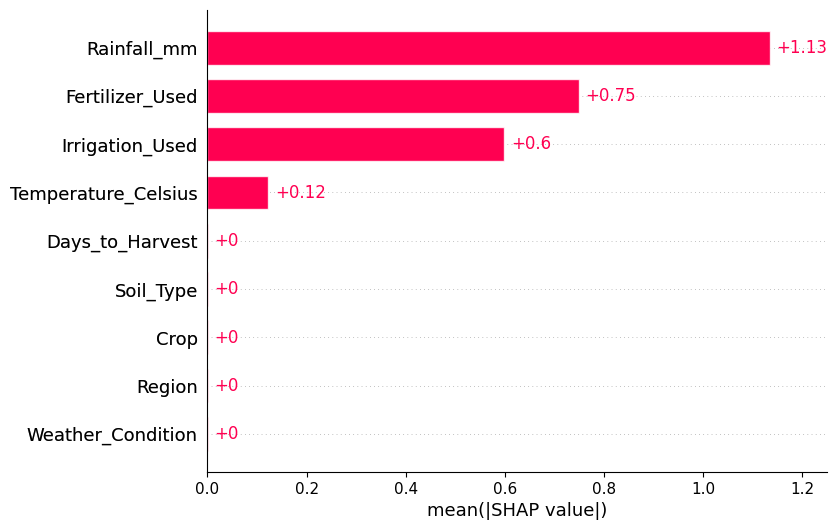

In [25]:
explication = shap.Explanation(
    values=shap_variables.to_numpy(),
    base_values=np.full(len(echantillon), valeur_de_base),
    data=echantillon[PREDICT_FEATURES].to_numpy(),
    feature_names=PREDICT_FEATURES,
)
shap.plots.bar(explication, max_display=9)

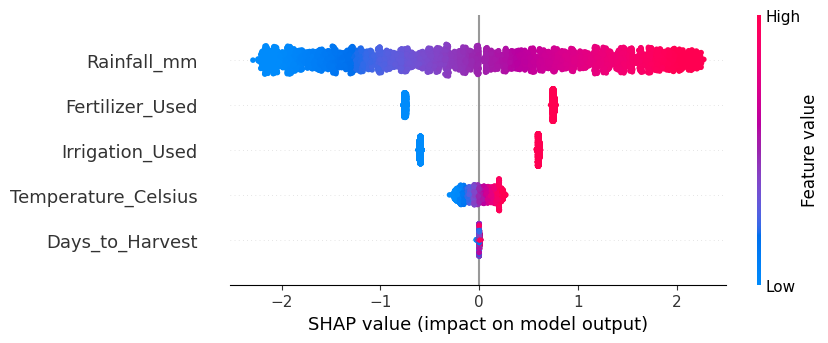

In [26]:
NUMERIQUES_ET_BOOLEENNES = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Fertilizer_Used", "Irrigation_Used"]

explication_numerique = shap.Explanation(
    values=shap_variables[NUMERIQUES_ET_BOOLEENNES].to_numpy(),
    base_values=np.full(len(echantillon), valeur_de_base),
    data=echantillon[NUMERIQUES_ET_BOOLEENNES].astype(float).to_numpy(),
    feature_names=NUMERIQUES_ET_BOOLEENNES,
)
shap.plots.beeswarm(explication_numerique)

**Observations :**

- Même hiérarchie que la permutation et Spearman.
- Plus de pluie, fertilisation, irrigation et température plus élevée poussent la prédiction vers le haut.

# Conclusion

**Observations :**

- la régression linéaire reste la meilleure référence ;
- les boostings restent très proches, sans gain sur la RMSE ; l'arbre seul et la forêt sont derrière ;
- pluie, fertilisation et irrigation dominent nettement ; la température a un effet plus faible ; les autres variables,
  dont les 3 supplémentaires, n'apportent rien ;
- prochaine étape : feature engineering ciblé avant de choisir le modèle à tuner.

Le test reste réservé à l'évaluation finale.

In [27]:
notify(
    "Agritech /predict",
    f"Modèles non linéaires terminés — meilleure RMSE CV {comparaison['cv_rmse_mean'].iloc[0]:.4f} ({comparaison.index[0]})",
)